In [49]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aljowharahalshabaan/projectw7/day35_project (1).csv


In [50]:
"""
Day 35 Activity: EDA Mini-Project
Tasks:
1) Run univariate, bivariate, and correlation analysis
2) Use at least 5 plots
3) Write 3 insights
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# TODO: Load data from data/day35_project.csv
df = pd.read_csv("/kaggle/input/datasets/aljowharahalshabaan/projectw7/day35_project (1).csv")

# TODO: Perform EDA and write insights

In [51]:
print("Shape:", df.shape, "\nDtypes:\n", df.dtypes)
missing = df.isna().sum().sort_values(ascending=False)
print("Missing:\n", missing)

Shape: (4, 4) 
Dtypes:
 age         int64
income      int64
spend       int64
segment    object
dtype: object
Missing:
 age        0
income     0
spend      0
segment    0
dtype: int64


In [52]:
numeric_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns
print("Numeric:", numeric_cols.tolist(), "\nCategorical:", cat_cols.tolist())

Numeric: ['age', 'income', 'spend'] 
Categorical: ['segment']


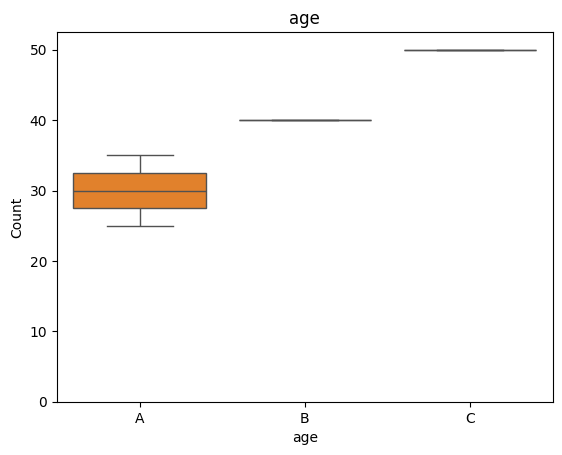

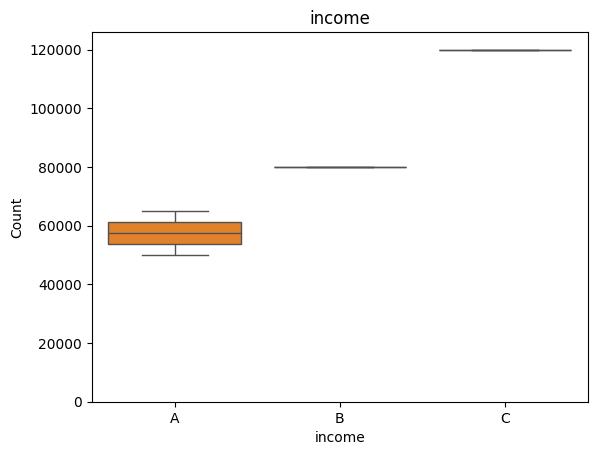

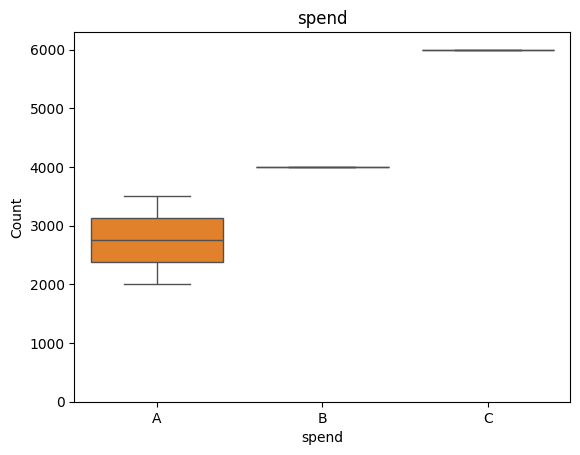

In [53]:
for col in numeric_cols[:4]:
    sns.histplot(df[col].dropna(), bins=30, kde=True); plt.title(f"{col}")
    sns.boxplot(x=cat_cols[0], y=col, data=df); plt.show()

* there is no outliers in age col
* there might be outliers in income col
* there is no outliers in spend col

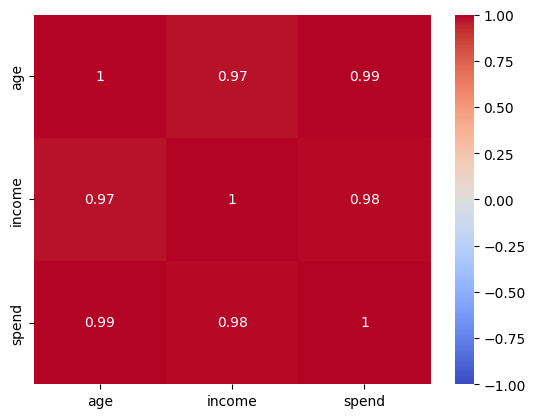

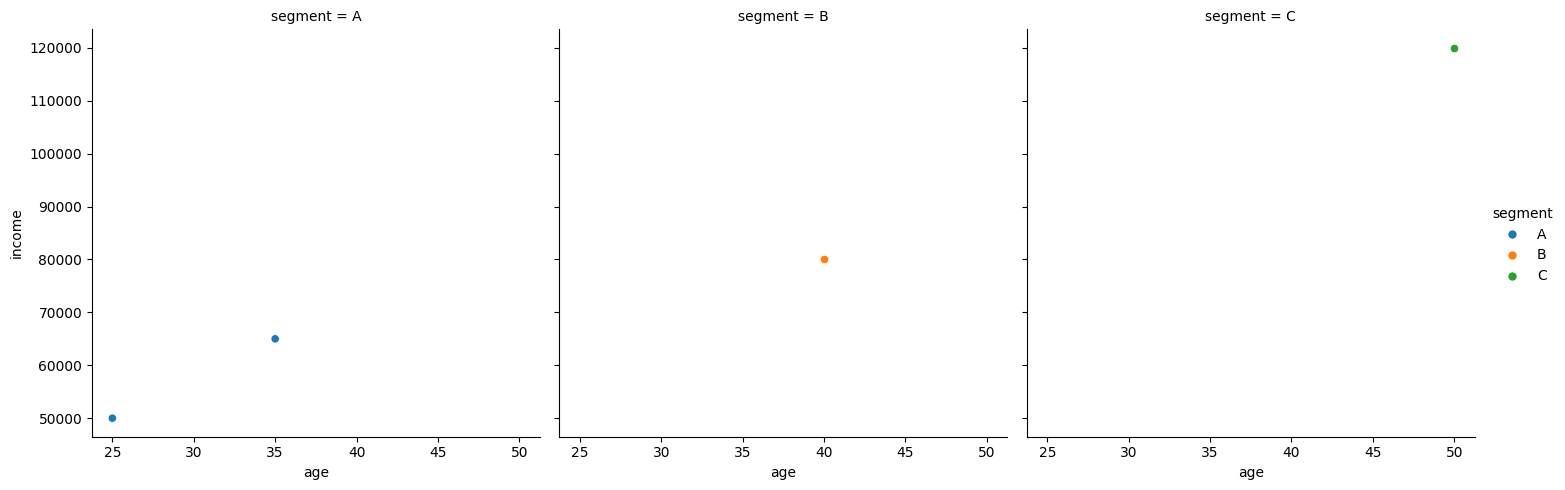

In [54]:
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", vmin=-1, vmax=1,annot=True)
g = sns.relplot(data=df, x=numeric_cols[0], y=numeric_cols[1],
hue=cat_cols[0], col=cat_cols[0], kind="scatter")


* age and spend are highly correlated pairs
* income and spend are highly correlated pairs
* maybe one of the cols is redundet


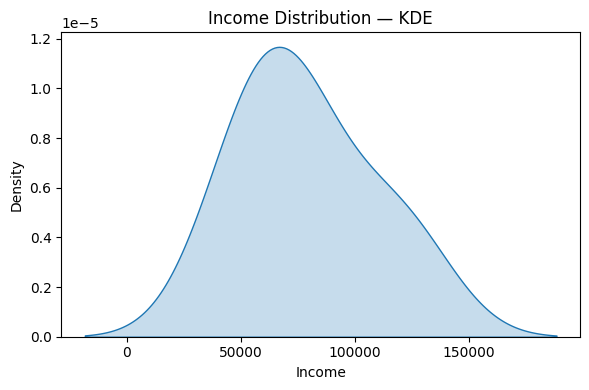

In [55]:
plt.figure(figsize=(6, 4))
sns.kdeplot(df["income"], fill=True)
plt.title("Income Distribution — KDE")
plt.xlabel("Income"); plt.ylabel("Density")
plt.tight_layout(); plt.show()

*  The curve represents the probability density of income values.
*  The distribution appears right-skewed

* 

Text(0.5, 1.0, 'Segment Distribution')

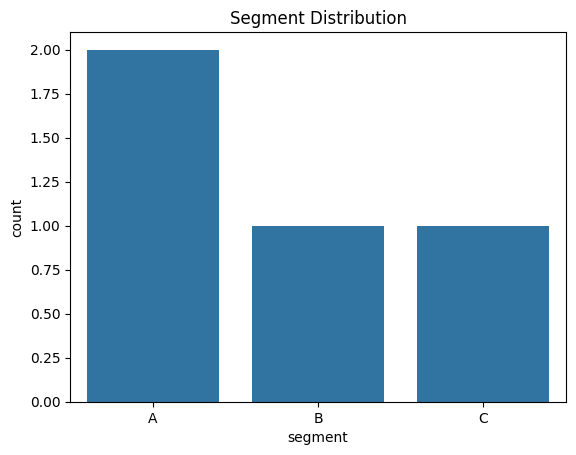

In [56]:
sns.countplot(data=df, x="segment"); plt.title("Segment Distribution")

* Segment **A** has the highest count.  
* Segments **B** and **C** have lower and similar counts.  

Text(0.5, 1.0, 'Value by Time Bucket and Segment')

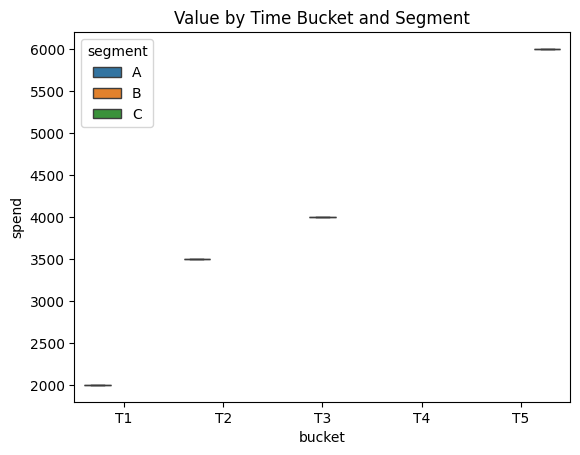

In [57]:
df["bucket"] = pd.cut(df["age"], bins=5, labels=["T1","T2","T3","T4","T5"])
sns.boxplot(data=df, x="bucket", y="spend", hue="segment")
plt.title("Value by Time Bucket and Segment")

* T1 has the lowest spend .
* T5 has the highest spend .
* trend shows strong and continuous growth in spend across the time periods.

In [58]:
actions=["Use robust scaling for outliers",
         "Drop highly correlated pairs",
        "Apply transformations to skewed features"]

In [59]:
#robust scaling
from sklearn.preprocessing import RobustScaler
rob_scaler = RobustScaler()
df[numeric_cols] = rob_scaler.fit_transform(df[numeric_cols])

In [60]:
#Drop highly correlated pairs
def drop_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop), to_drop
drop_correlated_features(df[numeric_cols])

(    age
 0 -1.25
 1  0.25
 2 -0.25
 3  1.25,
 ['income', 'spend'])

In [61]:
#Add interaction
df["income_divided_by_spend"]=df["income"]/df["spend"]

In [62]:
sensitive = [c for c in df.columns if "segment" in c.lower() or "age" in c.lower() or "zip" in
c.lower()]
print("Potential sensitive/proxy columns:", sensitive)

Potential sensitive/proxy columns: ['age', 'segment']


In [63]:
insights=["there is a probability skwe in income col",
         "there are outliers in income col",
         "there is no missing values"]

In [64]:
df.to_csv('/kaggle/working/cleaned_data.csv', index=False)